# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score

# LOAD DATASET

In [4]:
df = pd.read_csv("Books_df.csv")
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "_", regex=False)   
)

print(df)
df.head()

      unnamed:_0                                              title  \
0              0              The Complete Novel of Sherlock Holmes   
1              1  Black Holes (L) : The Reith Lectures [Paperbac...   
2              2                                    The Kite Runner   
3              3  Greenlights: Raucous stories and outlaw wisdom...   
4              4  The Science of Storytelling: Why Stories Make ...   
...          ...                                                ...   
7923        7923  Insight Guides Poland (Travel Guide with Free ...   
7924        7924              Lonely Planet India 19 (Travel Guide)   
7925        7925  Eyewitness Travel Phrase Book French (EW Trave...   
7926        7926             Lonely Planet Australia (Travel Guide)   
7927        7927  Political Map of India Latest Map of India Wit...   

                    author                main_genre                sub_genre  \
0       Arthur Conan Doyle  Arts, Film & Photography       Cinema 

,unnamed:_0,title,author,main_genre,sub_genre,type,price,rating,no__of_people_rated,urls
0,0,The Complete Novel of Sherlock Holmes,Arthur Conan Doyle,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹169.00,4.4,19923,https://www.amazon.in/Complete-Novels-Sherlock...
1,1,Black Holes (L) : The Reith Lectures [Paperbac...,Stephen Hawking,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹99.00,4.5,7686,https://www.amazon.in/Black-Holes-Lectures-Ste...
2,2,The Kite Runner,Khaled Hosseini,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹175.75,4.6,50016,https://www.amazon.in/Kite-Runner-Khaled-Hosse...
3,3,Greenlights: Raucous stories and outlaw wisdom...,Matthew McConaughey,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹389.00,4.6,32040,https://www.amazon.in/Greenlights-Raucous-stor...
4,4,The Science of Storytelling: Why Stories Make ...,Will Storr,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹348.16,4.5,1707,https://www.amazon.in/Science-Storytelling-Wil...


# DATA INSPECTION

In [7]:
print("Shape of dataset:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst few rows:")
df.head()
print("\nStatistical Summary:")
print(df.describe())

Shape of dataset: (7928, 10)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7928 entries, 0 to 7927
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   unnamed:_0           7928 non-null   int64  
 1   title                7928 non-null   str    
 2   author               7907 non-null   str    
 3   main_genre           7928 non-null   str    
 4   sub_genre            7928 non-null   str    
 5   type                 7928 non-null   str    
 6   price                7928 non-null   str    
 7   rating               7928 non-null   float64
 8   no__of_people_rated  7928 non-null   int64  
 9   urls                 7928 non-null   str    
dtypes: float64(1), int64(2), str(7)
memory usage: 619.5 KB

First few rows:

Statistical Summary:
       unnamed:_0       rating  no__of_people_rated
count   7928.0000  7928.000000          7928.000000
mean    3963.5000     4.260797          6479.312941
std  

In [67]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['unnamed:_0', 'title', 'author', 'main_genre', 'sub_genre', 'type', 'price', 'rating', 'no__of_people_rated', 'urls']


In [68]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7928 entries, 0 to 7927
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   unnamed:_0           7928 non-null   int64  
 1   title                7928 non-null   str    
 2   author               7907 non-null   str    
 3   main_genre           7928 non-null   str    
 4   sub_genre            7928 non-null   str    
 5   type                 7928 non-null   str    
 6   price                7928 non-null   str    
 7   rating               7928 non-null   float64
 8   no__of_people_rated  7928 non-null   int64  
 9   urls                 7928 non-null   str    
dtypes: float64(1), int64(2), str(7)
memory usage: 619.5 KB


In [69]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
unnamed:_0              0
title                   0
author                 21
main_genre              0
sub_genre               0
type                    0
price                   0
rating                  0
no__of_people_rated     0
urls                    0
dtype: int64


In [70]:
print("First few rows:")
df.head()


First few rows:


,unnamed:_0,title,author,main_genre,sub_genre,type,price,rating,no__of_people_rated,urls
0,0,The Complete Novel of Sherlock Holmes,Arthur Conan Doyle,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹169.00,4.4,19923,https://www.amazon.in/Complete-Novels-Sherlock...
1,1,Black Holes (L) : The Reith Lectures [Paperbac...,Stephen Hawking,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹99.00,4.5,7686,https://www.amazon.in/Black-Holes-Lectures-Ste...
2,2,The Kite Runner,Khaled Hosseini,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹175.75,4.6,50016,https://www.amazon.in/Kite-Runner-Khaled-Hosse...
3,3,Greenlights: Raucous stories and outlaw wisdom...,Matthew McConaughey,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹389.00,4.6,32040,https://www.amazon.in/Greenlights-Raucous-stor...
4,4,The Science of Storytelling: Why Stories Make ...,Will Storr,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹348.16,4.5,1707,https://www.amazon.in/Science-Storytelling-Wil...


In [71]:
print("Few last rows:")
df.tail()

Few last rows:


,unnamed:_0,title,author,main_genre,sub_genre,type,price,rating,no__of_people_rated,urls
7923,7923,Insight Guides Poland (Travel Guide with Free ...,Insight Travel Guide,Travel,Travel & Holiday Guides,Paperback,"₹1,326.00",4.7,16,https://www.amazon.in/Insight-Guides-Poland-Tr...
7924,7924,Lonely Planet India 19 (Travel Guide),Anirban Mahapatra,Travel,Travel & Holiday Guides,Paperback,₹850.00,4.4,187,https://www.amazon.in/Lonely-Planet-India-Trav...
7925,7925,Eyewitness Travel Phrase Book French (EW Trave...,DK,Travel,Travel & Holiday Guides,Paperback,₹307.00,4.5,168,https://www.amazon.in/Eyewitness-Travel-Phrase...
7926,7926,Lonely Planet Australia (Travel Guide),Andrew Bain,Travel,Travel & Holiday Guides,Kindle Edition,"₹1,814.50",4.7,267,https://www.amazon.in/Lonely-Planet-Australia-...
7927,7927,Political Map of India Latest Map of India Wit...,Wonder House Books,Travel,Travel & Holiday Guides,Poster,₹99.00,3.9,48,https://www.amazon.in/Political-Map-India-Terr...


In [72]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       unnamed:_0       rating  no__of_people_rated
count   7928.0000  7928.000000          7928.000000
mean    3963.5000     4.260797          6479.312941
std     2288.7608     0.910659         22082.884343
min        0.0000     0.000000             0.000000
25%     1981.7500     4.300000            63.000000
50%     3963.5000     4.500000           499.000000
75%     5945.2500     4.600000          2905.250000
max     7927.0000     5.000000        500119.000000


In [73]:
print("Unique Authors Sample:")
print(df["author"].unique()[:10])

Unique Authors Sample:
<StringArray>
[   'Arthur Conan Doyle',       'Stephen Hawking',       'Khaled Hosseini',
   'Matthew McConaughey',            'Will Storr',          'J.K. Rowling',
 'Shrayana Bhattacharya',          'Blake Snyder',             'Syd Field',
        'David Nicholls']
Length: 10, dtype: str


# DATA CLEANING

In [74]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "")
    m = re.search(r"([0-9]+(?:\.[0-9]+)?)", s)
    return float(m.group(1)) if m else np.nan

# Clean price
if "price" in df.columns:
    df["price_clean"] = df["price"].apply(clean_price)
else:
    df["price_clean"] = 0

# Clean rating
for col in ["rating", "avg_rating", "average_rating"]:
    if col in df.columns:
        df["rating_clean"] = pd.to_numeric(df[col], errors="coerce")
        break

# Author & Title
df["author"] = df.get("author", "Unknown").fillna("Unknown")
df["title"] = df.get("title", "").fillna("")

# Detect num_ratings
if "num_ratings" in df.columns:
    df.drop(columns=["num_ratings"], inplace=True)

# Use correct column from dataset
df["num_ratings"] = pd.to_numeric(df["no__of_people_rated"], errors="coerce")
print("Correlation check:")
print(df[["rating_clean", "num_ratings"]].corr())

# Target
df["target"] = (df["rating_clean"] >= 4.0).astype(int)

Correlation check:
              rating_clean  num_ratings
rating_clean      1.000000     0.083654
num_ratings       0.083654     1.000000


In [9]:
print("Shape after cleaning:", df.shape)
print("Columns after cleaning:")
print(df.columns.tolist())
df.head()


Shape after cleaning: (7928, 10)
Columns after cleaning:
['unnamed:_0', 'title', 'author', 'main_genre', 'sub_genre', 'type', 'price', 'rating', 'no__of_people_rated', 'urls']


,unnamed:_0,title,author,main_genre,sub_genre,type,price,rating,no__of_people_rated,urls
0,0,The Complete Novel of Sherlock Holmes,Arthur Conan Doyle,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹169.00,4.4,19923,https://www.amazon.in/Complete-Novels-Sherlock...
1,1,Black Holes (L) : The Reith Lectures [Paperbac...,Stephen Hawking,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹99.00,4.5,7686,https://www.amazon.in/Black-Holes-Lectures-Ste...
2,2,The Kite Runner,Khaled Hosseini,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹175.75,4.6,50016,https://www.amazon.in/Kite-Runner-Khaled-Hosse...
3,3,Greenlights: Raucous stories and outlaw wisdom...,Matthew McConaughey,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹389.00,4.6,32040,https://www.amazon.in/Greenlights-Raucous-stor...
4,4,The Science of Storytelling: Why Stories Make ...,Will Storr,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹348.16,4.5,1707,https://www.amazon.in/Science-Storytelling-Wil...


In [76]:
print("Columns after cleaning:")
print(df.columns.tolist())



Columns after cleaning:
['unnamed:_0', 'title', 'author', 'main_genre', 'sub_genre', 'type', 'price', 'rating', 'no__of_people_rated', 'urls', 'price_clean', 'rating_clean', 'num_ratings', 'target']


In [77]:
df.head(10)



,unnamed:_0,title,author,main_genre,sub_genre,type,price,rating,no__of_people_rated,urls,price_clean,rating_clean,num_ratings,target
0,0,The Complete Novel of Sherlock Holmes,Arthur Conan Doyle,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹169.00,4.4,19923,https://www.amazon.in/Complete-Novels-Sherlock...,169.00,4.4,19923,1
1,1,Black Holes (L) : The Reith Lectures [Paperbac...,Stephen Hawking,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹99.00,4.5,7686,https://www.amazon.in/Black-Holes-Lectures-Ste...,99.00,4.5,7686,1
2,2,The Kite Runner,Khaled Hosseini,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹175.75,4.6,50016,https://www.amazon.in/Kite-Runner-Khaled-Hosse...,175.75,4.6,50016,1
3,3,Greenlights: Raucous stories and outlaw wisdom...,Matthew McConaughey,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹389.00,4.6,32040,https://www.amazon.in/Greenlights-Raucous-stor...,389.00,4.6,32040,1
4,4,The Science of Storytelling: Why Stories Make ...,Will Storr,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹348.16,4.5,1707,https://www.amazon.in/Science-Storytelling-Wil...,348.16,4.5,1707,1
5,5,Fantastic Beasts and Where to Find Them: The O...,J.K. Rowling,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹313.95,4.5,15122,https://www.amazon.in/Fantastic-Beasts-Where-F...,313.95,4.5,15122,1
6,6,Fantastic Beasts: The Crimes of Grindelwald - ...,J.K. Rowling,"Arts, Film & Photography",Cinema & Broadcast,Kindle Edition,₹313.95,4.6,10152,https://www.amazon.in/Fantastic-Beasts-Grindel...,313.95,4.6,10152,1
7,7,Desperately Seeking Shah Rukh : India's Lonely...,Shrayana Bhattacharya,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹348.16,4.5,539,https://www.amazon.in/Desperately-Seeking-Shah...,348.16,4.5,539,1
8,8,Save the Cat!: The Last Book on Screenwriting ...,Blake Snyder,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹850.00,4.5,7060,https://www.amazon.in/Save-Cat-Last-Screenwrit...,850.00,4.5,7060,1
9,9,Screenplay,Syd Field,"Arts, Film & Photography",Cinema & Broadcast,Paperback,₹644.52,4.5,3216,https://www.amazon.in/Screenplay-Foundations-S...,644.52,4.5,3216,1


In [78]:
print("Missing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
unnamed:_0             0
title                  0
author                 0
main_genre             0
sub_genre              0
type                   0
price                  0
rating                 0
no__of_people_rated    0
urls                   0
price_clean            0
rating_clean           0
num_ratings            0
target                 0
dtype: int64


In [79]:
print("Data types:")
print(df.dtypes)


Data types:
unnamed:_0               int64
title                      str
author                     str
main_genre                 str
sub_genre                  str
type                       str
price                      str
rating                 float64
no__of_people_rated      int64
urls                       str
price_clean            float64
rating_clean           float64
num_ratings              int64
target                   int64
dtype: object


In [80]:

df[["title", "author", "price_clean", "rating_clean", "num_ratings"]].head(10)

,title,author,price_clean,rating_clean,num_ratings
0,The Complete Novel of Sherlock Holmes,Arthur Conan Doyle,169.00,4.4,19923
1,Black Holes (L) : The Reith Lectures [Paperbac...,Stephen Hawking,99.00,4.5,7686
2,The Kite Runner,Khaled Hosseini,175.75,4.6,50016
3,Greenlights: Raucous stories and outlaw wisdom...,Matthew McConaughey,389.00,4.6,32040
4,The Science of Storytelling: Why Stories Make ...,Will Storr,348.16,4.5,1707
5,Fantastic Beasts and Where to Find Them: The O...,J.K. Rowling,313.95,4.5,15122
6,Fantastic Beasts: The Crimes of Grindelwald - ...,J.K. Rowling,313.95,4.6,10152
7,Desperately Seeking Shah Rukh : India's Lonely...,Shrayana Bhattacharya,348.16,4.5,539
8,Save the Cat!: The Last Book on Screenwriting ...,Blake Snyder,850.00,4.5,7060
9,Screenplay,Syd Field,644.52,4.5,3216


# EXPLORATORY DATA ANALYSIS(EDA)

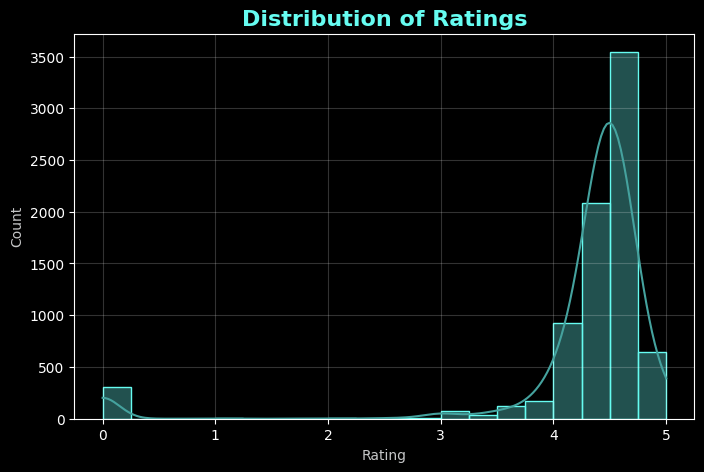

In [81]:
#RATING DISTRIBUTION
plt.style.use("dark_background")

plt.figure(figsize=(8,5))
sns.histplot(
    df["rating_clean"].dropna(),
    bins=20,
    kde=True,
    color="#45A29E",
    edgecolor="#66FCF1",
    linewidth=1
)

plt.title("Distribution of Ratings", fontsize=16, color="#66FCF1", fontweight="bold")
plt.xlabel("Rating", color="#C5C6C7")
plt.ylabel("Count", color="#C5C6C7")

plt.grid(alpha=0.2)
plt.show()

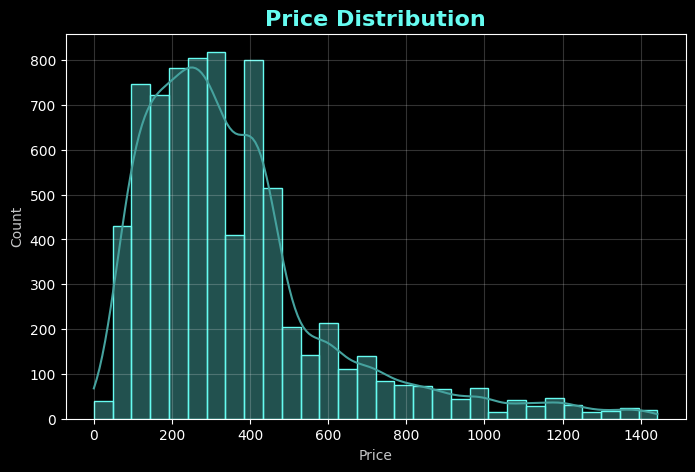

In [82]:
#PRICE DISTRIBUTION
price_data = df["price_clean"].dropna()
price_data = price_data[price_data < price_data.quantile(0.95)]

plt.figure(figsize=(8,5))
sns.histplot(
    price_data,
    bins=30,
    kde=True,
    color="#45A29E",
    edgecolor="#66FCF1",
    linewidth=1
)

plt.title("Price Distribution", fontsize=16, color="#66FCF1", fontweight="bold")
plt.xlabel("Price", color="#C5C6C7")
plt.ylabel("Count", color="#C5C6C7")

plt.grid(alpha=0.2)
plt.show()

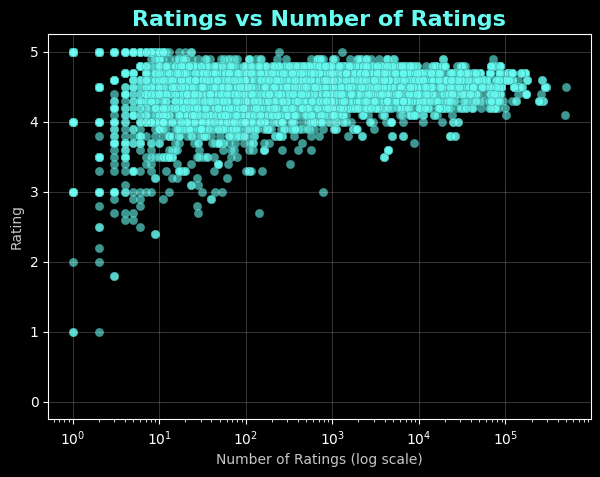

In [83]:
#Ratings vs Number of Ratings
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["num_ratings"],
    y=df["rating_clean"],
    color="#66FCF1",
    alpha=0.6,
    edgecolor="#45A29E"
)

plt.xscale("log")

plt.title("Ratings vs Number of Ratings", fontsize=16, color="#66FCF1", fontweight="bold")
plt.xlabel("Number of Ratings (log scale)", color="#C5C6C7")
plt.ylabel("Rating", color="#C5C6C7")

plt.grid(alpha=0.2)
plt.show()

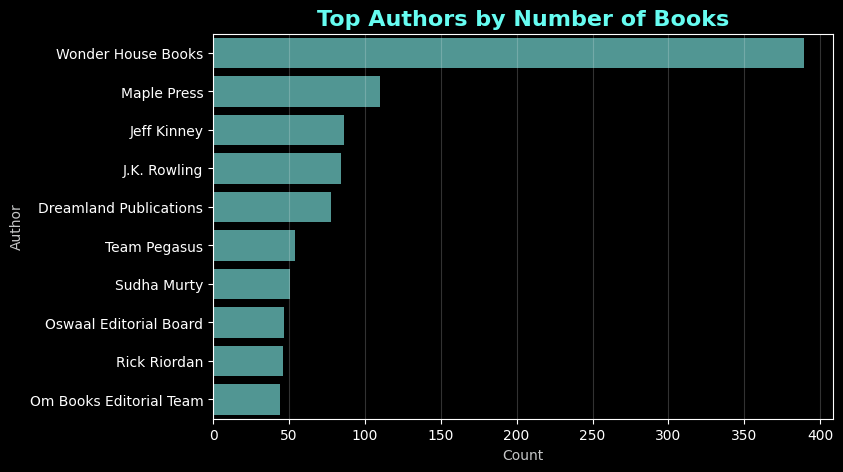

In [84]:
#TOP AUTHORS
top_authors = df["author"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_authors.values,
    y=top_authors.index,
    color="#45A29E"
)

plt.title("Top Authors by Number of Books", fontsize=16, color="#66FCF1", fontweight="bold")
plt.xlabel("Count", color="#C5C6C7")
plt.ylabel("Author", color="#C5C6C7")

plt.grid(axis="x", alpha=0.2)
plt.show()

# FEATURE ENGINEERING

In [85]:
#Target Variable (High Rating Classification)
df["target"] = (df["rating_clean"] >= 4.0).astype(int)

#Select Important Features
features = ["title", "author", "price_clean", "num_ratings"]

#Handle Missing Values
df[features] = df[features].fillna({
    "title": "",
    "author": "Unknown",
    "price_clean": 0,
    "num_ratings": 0
})

#Final Feature Matrix
X = df[features]
y = df["target"]

print("Feature Engineering Completed")
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

Feature Engineering Completed
X shape: (7928, 4)
y distribution:
target
1    7196
0     732
Name: count, dtype: int64


In [86]:
#CLASS BALANCE
y.value_counts(normalize=True)

target
1    0.907669
0    0.092331
Name: proportion, dtype: float64

# FEATURE ENCODING AND TRANSFORMTION

In [87]:
text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=800, stop_words="english")),
    ("svd", TruncatedSVD(n_components=15, random_state=42))
])

preprocessor = ColumnTransformer([
    ("title", text_pipeline, "title"),
    ("author", OneHotEncoder(handle_unknown="ignore"), ["author"]),
    ("num", StandardScaler(), ["price_clean", "num_ratings"])
])

# MODEL TRAINING (CLASSIFICATION)

In [88]:

X = df[["title", "author", "price_clean", "num_ratings"]]
y = df["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=80, random_state=42))
])

# ONLY TRAIN on TRAIN DATA
clf.fit(X_train, y_train)

# ONLY TEST on TEST DATA
preds = clf.predict(X_test)

# Predict
preds = clf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_test, preds)
print("Accuracy:", round(acc, 3))

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.966

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.67      0.78       146
           1       0.97      1.00      0.98      1440

    accuracy                           0.97      1586
   macro avg       0.95      0.83      0.88      1586
weighted avg       0.97      0.97      0.96      1586


Confusion Matrix:

[[  98   48]
 [   6 1434]]


# REGRESSION MODEL

In [89]:


y_reg = df["rating_clean"].fillna(df["rating_clean"].median())

reg = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestRegressor(n_estimators=80, random_state=42))
])

reg.fit(X, y_reg)

print("Regression model trained successfully")

Regression model trained successfully


# CLUSTERING (MARKET SEGMENTATION)

In [90]:

M = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(M)

df["cluster"] = clusters

from sklearn.metrics import silhouette_score

score = silhouette_score(M, clusters)
print("Silhouette Score:", score)

df["cluster"].value_counts()

Silhouette Score: 0.43913561177773297


cluster
1    7335
2     343
0     237
3      13
Name: count, dtype: int64

# CLUSTER ANALYSIS 

In [91]:


cluster_profile = df.groupby("cluster").agg({
    "price_clean": "mean",
    "rating_clean": "mean",
    "num_ratings": "mean"
}).round(2)

cluster_profile

,price_clean,rating_clean,num_ratings
cluster,,,
0,397.55,4.56,107621.10
1,364.58,4.25,3458.89
2,2684.62,4.30,1423.08
3,16701.98,3.46,210.85


# RECOMMENDATION SYSTEM

In [92]:


nn = NearestNeighbors(n_neighbors=5, metric="cosine")
nn.fit(M)

def recommend(book_name):
    matches = df[df["title"].str.contains(book_name, case=False, na=False)]
    
    if matches.empty:
        return "Book not found"
    
    idx = matches.index[0]
    distances, indices = nn.kneighbors(M[idx].reshape(1, -1))
    
    return df.iloc[indices[0]][["title", "author"]]

# Example
recommend("Harry Potter")

,title,author
33,The Magic of MinaLima: Celebrating the Graphic...,MinaLima
7763,Harry Potter - The Illustrated Collection,J. K. Rowling
7742,Harry Potter and the Prisoner of Azkaban: Mina...,J.K. Rowling
932,Harry Potter and the Prisoner of Azkaban: Mina...,J.K. Rowling
4031,Point-of-Care Ultrasound for the Neonatal and ...,Yogen Singh
